In [1]:
#Step-1:Data loading
import pandas as pd
df=pd.read_excel(r"C:\Users\shaik\Downloads\foodtrends_facebook_cleaned (1).xlsx")

In [2]:
#Step-2:Data overview
df.head()
df.tail()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   post_id           1000 non-null   int64         
 1   post_type         1000 non-null   object        
 2   food_category     1000 non-null   object        
 3   brand_name        1000 non-null   object        
 4   post_date         1000 non-null   datetime64[ns]
 5   post_time         1000 non-null   int64         
 6   likes_count       1000 non-null   int64         
 7   comments_count    1000 non-null   int64         
 8   shares_count      1000 non-null   int64         
 9   love              1000 non-null   int64         
 10  wow               1000 non-null   int64         
 11  sad               1000 non-null   int64         
 12  angry             1000 non-null   int64         
 13  day_of_week       1000 non-null   object        
 14  time_of_day       1000 no

In [3]:
#step-3-data cleaning
df.isnull().sum()

post_id             0
post_type           0
food_category       0
brand_name          0
post_date           0
post_time           0
likes_count         0
comments_count      0
shares_count        0
love                0
wow                 0
sad                 0
angry               0
day_of_week         0
time_of_day         0
total_engagement    0
dtype: int64

In [4]:
#Step-4:Statistical summary
df.describe()

,post_id,post_date,post_time,likes_count,comments_count,shares_count,love,wow,sad,angry,total_engagement
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2025-01-21 08:03:50.400000,11.436000,99.807000,19.950000,10.040000,20.283000,5.004000,2.094000,1.086000,129.797000
min,1.000000,2025-01-01 00:00:00,0.000000,67.000000,8.000000,2.000000,7.000000,0.000000,0.000000,0.000000,97.000000
25%,250.750000,2025-01-11 00:00:00,5.000000,93.000000,17.000000,8.000000,17.000000,3.000000,1.000000,0.000000,122.000000
50%,500.500000,2025-01-21 00:00:00,11.000000,100.000000,20.000000,10.000000,20.000000,5.000000,2.000000,1.000000,130.000000
75%,750.250000,2025-02-01 00:00:00,17.000000,107.000000,23.000000,12.000000,23.000000,7.000000,3.000000,2.000000,138.000000
max,1000.000000,2025-02-11 00:00:00,23.000000,130.000000,35.000000,20.000000,37.000000,15.000000,8.000000,7.000000,167.000000
std,288.819436,NaN,6.913009,9.941357,4.497525,3.178443,4.451373,2.297665,1.457837,1.061947,11.478307


In [5]:
#Step-5:EDA
#Import libraries
import matplotlib.pyplot as plt
import seaborn as sns


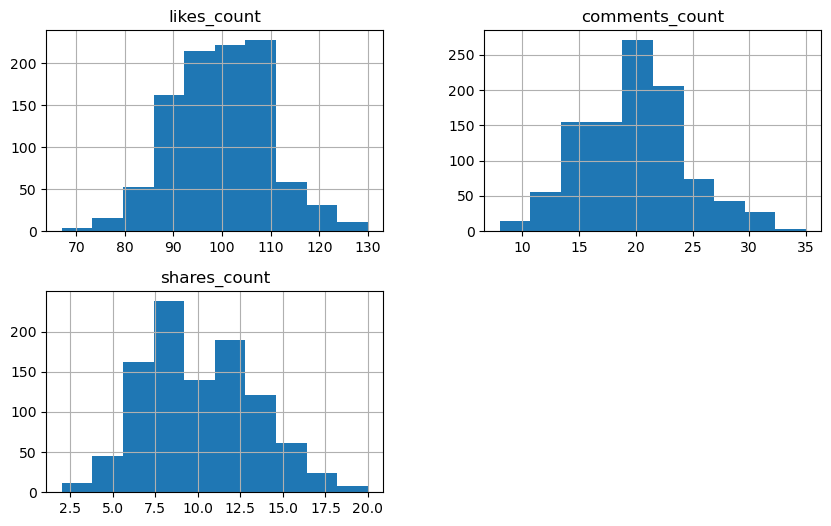

In [10]:
#Overall Engagement Analysis
df[['likes_count', 'comments_count', 'shares_count', 'total_engagement']].describe()
df[['likes_count', 'comments_count', 'shares_count']].hist(figsize=(10,6))
plt.show()

food_category
burger    130.076046
sushi     129.965251
pizza     129.861423
salad     129.161137
Name: total_engagement, dtype: float64


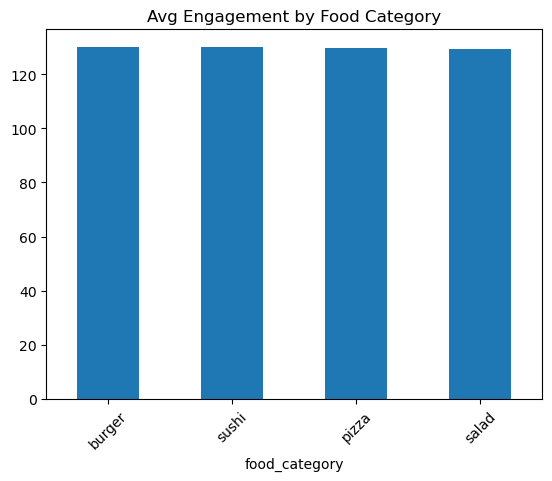

In [11]:
#Food category-wise analysis
category_engagement = df.groupby('food_category')['total_engagement'].mean().sort_values(ascending=False)
print(category_engagement)
category_engagement.plot(kind='bar')
plt.title("Avg Engagement by Food Category")
plt.xticks(rotation=45)
plt.show()

brand_name
subway       131.004167
dominos      130.229885
mcdonalds    129.255814
chipotle     128.705394
Name: total_engagement, dtype: float64


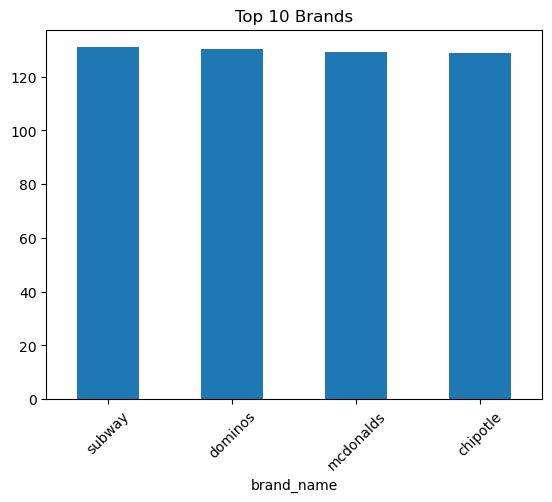

In [12]:
#Brand-wise performance
brand_engagement = df.groupby('brand_name')['total_engagement'].mean().sort_values(ascending=False)
print(brand_engagement.head(10))
brand_engagement.head(10).plot(kind='bar')
plt.title("Top 10 Brands")
plt.xticks(rotation=45)
plt.show()

post_type
image    129.700000
video    129.890196
Name: total_engagement, dtype: float64


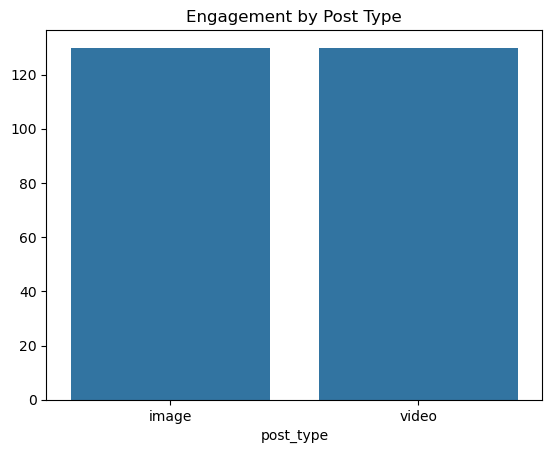

In [13]:
#Post type analysis
post_type_engagement = df.groupby('post_type')['total_engagement'].mean()
print(post_type_engagement)
sns.barplot(x=post_type_engagement.index, y=post_type_engagement.values)
plt.title("Engagement by Post Type")
plt.show()

time_of_day
afternoon    129.000000
evening      130.146341
morning      129.914966
night        130.021021
Name: total_engagement, dtype: float64


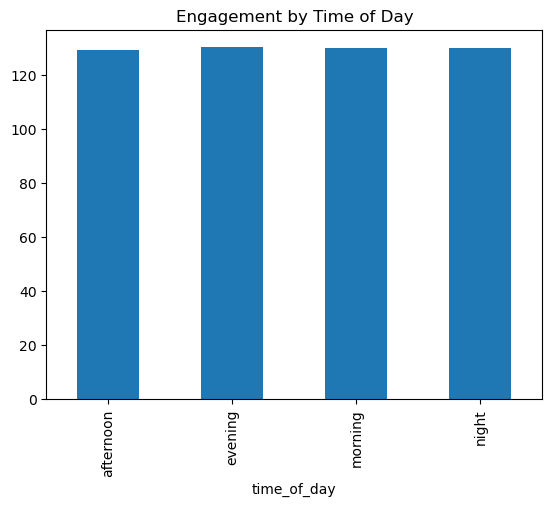

In [14]:
#Time-based analysis
time_engagement = df.groupby('time_of_day')['total_engagement'].mean()
print(time_engagement)
time_engagement.plot(kind='bar')
plt.title("Engagement by Time of Day")
plt.show()

day_of_week
Friday       127.756944
Monday       128.347222
Saturday     128.701389
Sunday       131.270833
Thursday     129.965278
Tuesday      132.529412
Wednesday    130.159722
Name: total_engagement, dtype: float64


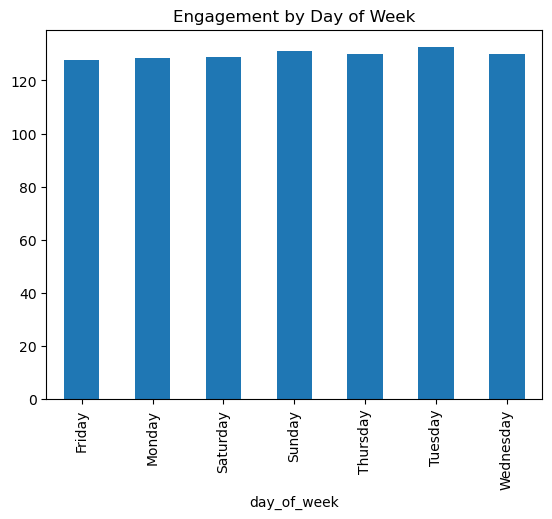

In [15]:
day_engagement = df.groupby('day_of_week')['total_engagement'].mean()
print(day_engagement)
day_engagement.plot(kind='bar')
plt.title("Engagement by Day of Week")
plt.show()

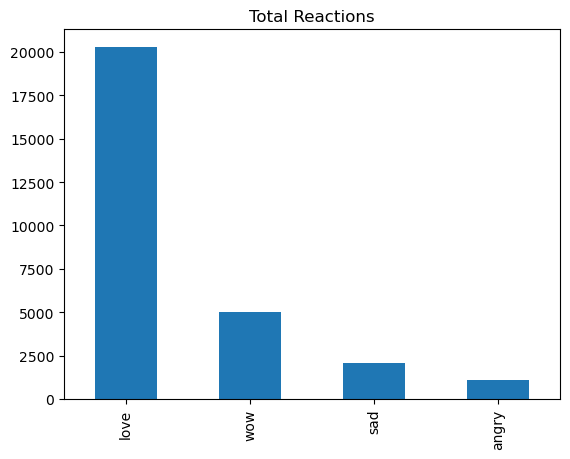

In [16]:
#Reaction analysis
reaction_cols = ['love', 'wow', 'sad', 'angry']
df[reaction_cols].describe()
df[reaction_cols].sum().plot(kind='bar')
plt.title("Total Reactions")
plt.show()

                  likes_count  comments_count  shares_count  total_engagement
likes_count          1.000000        0.028373     -0.009228          0.874662
comments_count       0.028373        1.000000      0.022268          0.422569
shares_count        -0.009228        0.022268      1.000000          0.277642
total_engagement     0.874662        0.422569      0.277642          1.000000


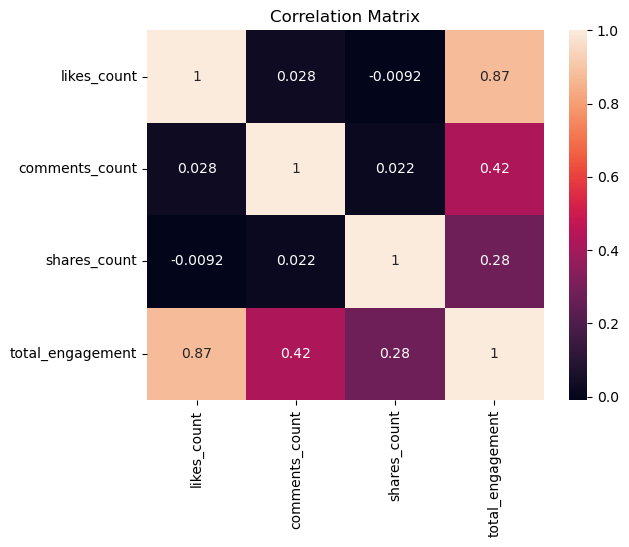

In [17]:
#Correlatio analysis
corr = df[['likes_count', 'comments_count', 'shares_count', 'total_engagement']].corr()
print(corr)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

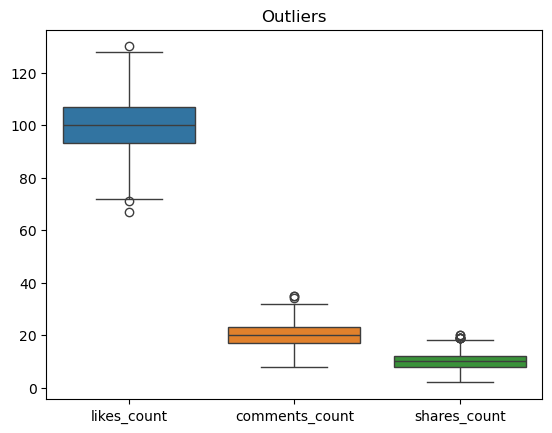

In [19]:
#Outlier detection
sns.boxplot(data=df[['likes_count', 'comments_count', 'shares_count']])
plt.title("Outliers")
plt.show()

In [18]:
#Top performing posts
top_posts = df.sort_values(by='total_engagement', ascending=False).head(5)
print(top_posts[['post_id', 'brand_name', 'total_engagement']])

     post_id brand_name  total_engagement
525      526   chipotle               167
489      490     subway               163
723      724     subway               162
574      575    dominos               162
84        85    dominos               160
